# Phase 4: Stress endpoint selection


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import kneighbors_graph
from scipy.spatial.distance import pdist, squareform
from scipy.sparse.csgraph import connected_components, shortest_path
from scipy.sparse import csr_matrix

In [3]:
fred_md = pd.read_csv("./datasets/FRED_MD_2026_05.csv")

transforms = fred_md.loc[fred_md["sasdate"] == "Transform:"].iloc[0].drop("sasdate")
transforms = transforms.astype(int).to_dict()

fred_md = fred_md[fred_md["sasdate"] != "Transform:"].copy()
fred_md["sasdate"] = pd.to_datetime(fred_md["sasdate"], format="%m/%d/%Y")
fred_md = fred_md.set_index("sasdate")
fred_md = fred_md.apply(pd.to_numeric, errors="coerce")
fred_md = fred_md.sort_index()
fred_md = fred_md.loc["1963-6-01":"2026-04-01"]
 
selected_cols = [
    # (i) Output and activity
    "RPI",
    # (ii) Employment
    "UNRATE",
    # (iii) Inflation
    "CPIAUCSL",
    # (iv) Interest rates and term spreads
    "FEDFUNDS",
    # (v) Credit spreads
    "AAA",
    # (vi) Money and liquidity
    "M2SL",
    # (vii) Financial market stress proxies
    "S&P 500",
    # (ix) Housing
    "HOUST"]

def transform_series(x, tcode, lag=1):
    x = x.astype(float)
    if   tcode == 1: return x
    elif tcode == 2: return x.diff(lag)
    elif tcode == 3: return x.diff(lag).diff(1)
    elif tcode == 4: return np.log(x)
    elif tcode == 5: return np.log(x).diff(lag)
    elif tcode == 6: return np.log(x).diff(lag).diff(1)
    elif tcode == 7: return x.pct_change(lag).diff(1)
    else: raise ValueError(f"Unknown transformation code: {tcode}")


fred_md["CPI_YoY"] = transform_series(fred_md["CPIAUCSL"], 5, 12)

In [4]:
def diffusion_map(data, eps, alpha=1, k=4):
    Dsq = squareform(pdist(data)**2)
    Wm = np.exp(-Dsq/eps); q = Wm.sum(1)
    Wa = Wm/np.outer(q**alpha, q**alpha)
    da = Wa.sum(1); Dis = 1.0/np.sqrt(da)
    S = Dis[:, None]*Wa*Dis[None, :]                
    w, v = np.linalg.eigh(S)
    idx = np.argsort(w)[::-1]; w, v = w[idx], v[:, idx]
    phi = Dis[:, None]*v                             
    Psi = phi[:, 1:k+1]*w[1:k+1]                     
    return {"evals": w, "Psi": Psi, "phi": phi, "W": Wm, "degrees": q}

def graph_degree_density(Psi, h):
    Dsq = squareform(pdist(Psi)**2)
    rho = np.exp(-Dsq/h).sum(1)
    rho = rho/rho.mean()
    rho = np.maximum(rho, 1e-6)   # [C9] tiny floor only for log-stability; an aggressive
    # quantile floor saturates the min-density metric so it cannot discriminate paths
    return rho, -np.log(rho)

def reconstruct_path(pred, start, end):
    path = [end]; current = end
    while current != start:
        current = pred[start, current]
        if current == -9999:
            return None
        path.append(current)
    return path[::-1]

def density_aware_cost(A_dist_sym, V, beta):
    rows, cols = A_dist_sym.nonzero()
    base = np.asarray(A_dist_sym[rows, cols]).ravel()
    costs = base*np.exp(beta*(V[rows]+V[cols])/2)
    return csr_matrix((costs, (rows, cols)), shape=A_dist_sym.shape)

df = pd.read_parquet("./datasets/joint_df_quantile.parquet")
# df = df.clip(-3, 3); 
Z = df.to_numpy()[:, :-1]; N = Z.shape[0]
dates = df.index; variables = df.columns
diff = diffusion_map(Z, eps=3, k=3); Psi = diff["Psi"]

### 7.3: Paths to compute
Here I inspect the time series to find pairs of time points with the desired qualities.

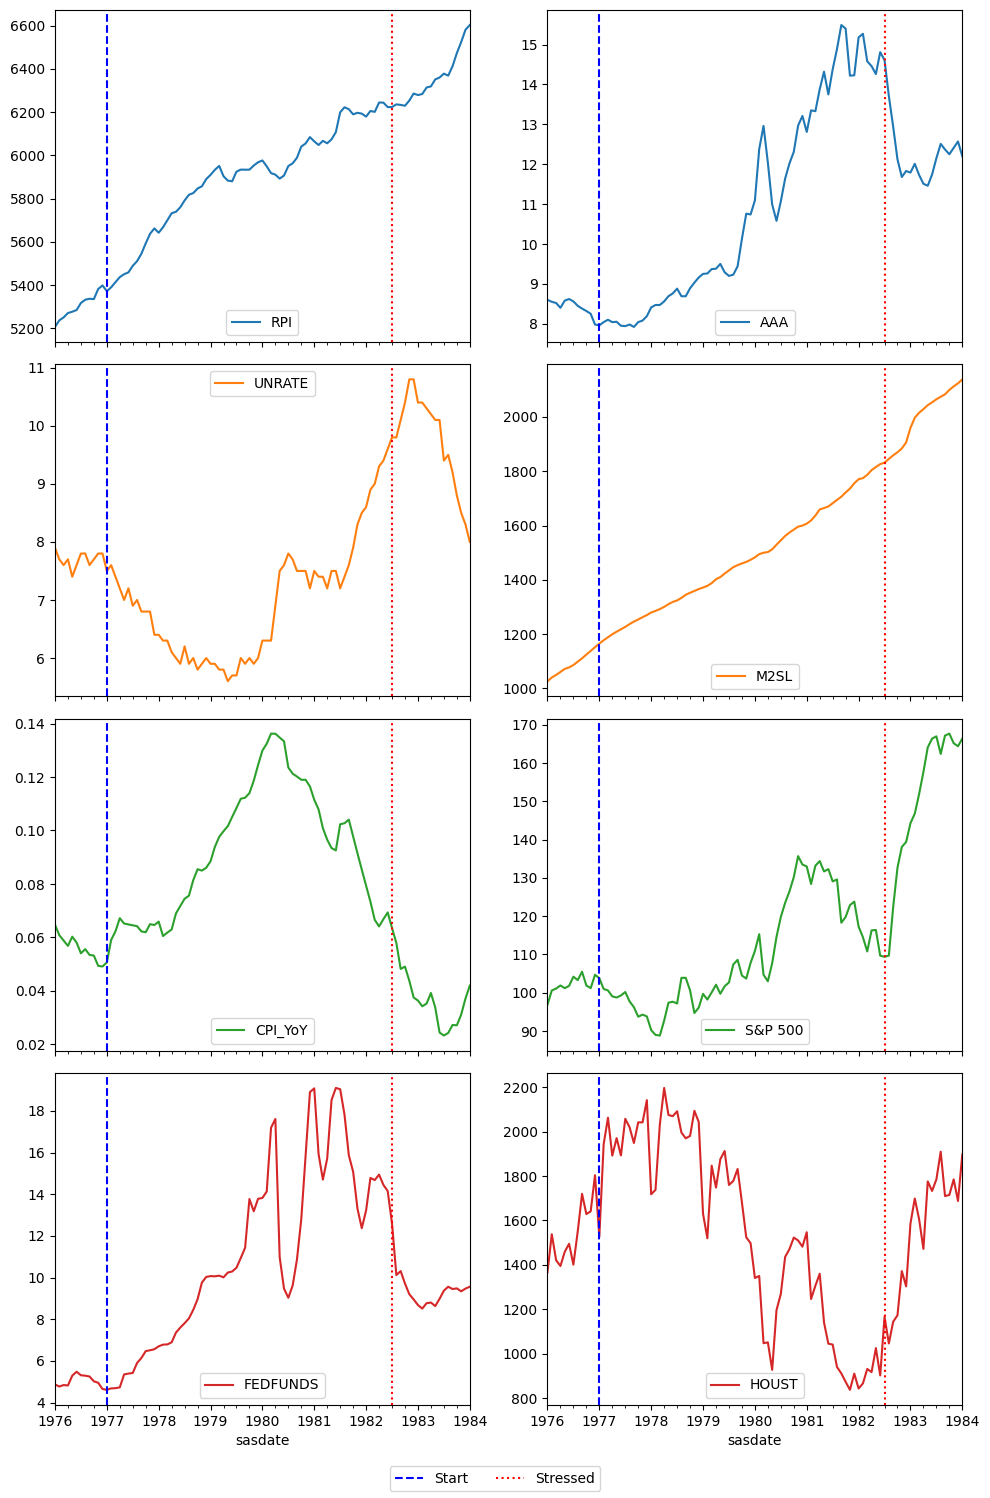

In [5]:
selected_vars = ['RPI', 'UNRATE', 'CPI_YoY', 'FEDFUNDS', 'AAA', 'M2SL', 'S&P 500', 'HOUST']

def plot_variables_in_period(selected_vars, start, end, point1=None, point2=None):
    if len(selected_vars) > 8:
        raise ValueError("Too many variables to plot")
    
    fred_md_selected = fred_md[selected_vars]
    fred_md_selected_ref = fred_md_selected.loc[start: end]
    num_rows = 4; num_cols = 2
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(10, 15), sharex=True)

    col1_axes = axes[:, 0]; col2_axes = axes[:, 1]

    fred_md_selected_ref[selected_vars[:4]].plot(subplots=True, ax=col1_axes[:4])
    fred_md_selected_ref[selected_vars[4:8]].plot(subplots=True, ax=col2_axes[:len(selected_vars[4:8])])

    for ax in axes.flat:
        if not ax.has_data():
            ax.set_visible(False)
            continue

        if point1 and point2:
            line1 = ax.axvline(x=point1, color='blue', linestyle='--', linewidth=1.5, label='Start')
            line2 = ax.axvline(x=point2, color='red', linestyle=':', linewidth=1.5, label='Stressed')

    if point1 and point2:
        fig.legend(handles=[line1, line2],  loc='lower center', ncol=2)

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.06) 
    plt.show()

plot_variables_in_period(selected_vars, start="1976-01-01", end="1984-01-01", point1="1977-01-01", point2="1982-07-01")

1. benign expansion date to Global Financial Crisis stress date: 2006-03-01 -> 2008-10-01
    - An example of each macro category looks very stable around the March 2006. All the diffusion points in 2006 are in the high density region.
    - Late 2008 is the height of the crisis, and October 2008 is a clear outlier in the diffusion coordinates.

2. benign expansion date to COVID shock date: 2019-07-01 -> 2020-04-01
    - July 2019 was a very stable time as marked by the 8 macroeconomic variables.
    - March 2020 was the point where COVID closed US schools, this month has come up multiple times in preprocessing as a clear outlier

3. low-inflation date to post-2021 inflation or tightening date: 2019-04-01 -> 2021-06-01 / 2022-04-01
    - 2019-04-01, inflation was low (YoY percentage change in CPI was ~0.2 for the 8 months before and after this date), and the economy looked to be in a normal state.
    - 2021-06-01, YoY inflation rate change shot up from ~2% to ~6% from Feb-June of 2021, this is a clear structural break.
    - Tightning date: 2022-04-01, the FED rate was at rock bottom for the 20 months before this date and it shot up on this date.

4. pre-crisis date to recession trough date: 1977-01-01 -> 1982-07-01
    - Economy was stable in 1977-01-01
    - July 1982: Unemployment was nearly at its peak of 11%, number of new houses being built was near the local minimum, SP500 index was at a 2 year low, interest rates were still very high ~12%


In [6]:
endpoint_pairs = {"GFC": ("2006-03-01", "2008-10-01"), "COVID": ("2019-07-01", "2020-04-01"), "Inflation": ("2019-04-01", "2021-06-01"), "Fiscal Tightening": ("2019-04-01", "2022-04-01"), "Recession Trough": ("1977-01-01", "1982-07-01")}

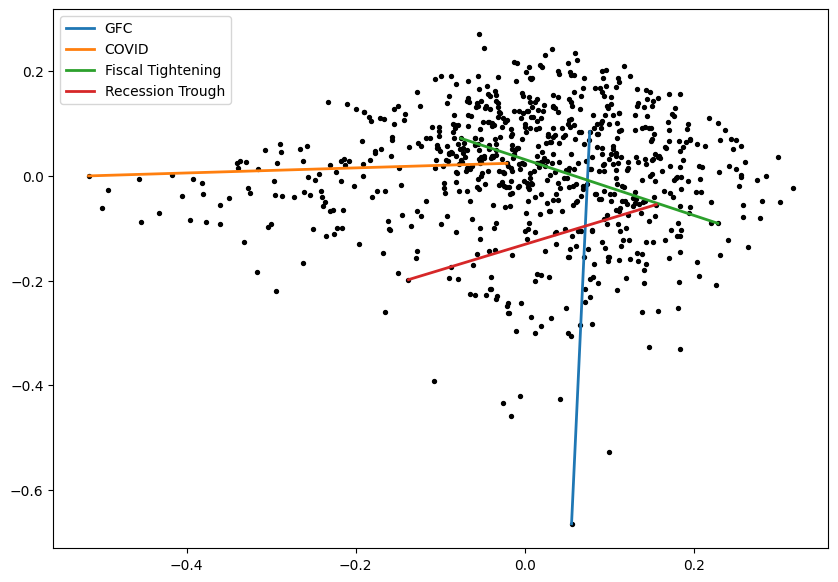

In [ ]:
fig, ax = plt.subplots()
fig.set_figheight(7); fig.set_figwidth(10)
ax.scatter(Psi[:,0], Psi[:,1], s=8, c="k")

for event, pair in endpoint_pairs.items():
    start, end = dates.get_loc(pair[0]), dates.get_loc(pair[1])
    ax.plot([Psi[start, 0], Psi[end, 0]], [Psi[start, 1], Psi[end, 1]], label=event, linewidth=2)

plt.legend(); plt.show()

These pairs all give us a good path across the point cloud, apart from "Inflation". Inflation is a short path from 2 high density regions which is not what I am looking for. I will remove these points from the dictionary

In [17]:
endpoint_pairs = {"GFC": ("2006-03-01", "2008-10-01"), "COVID": ("2019-07-01", "2020-04-01"), "Fiscal Tightening": ("2019-04-01", "2022-04-01"), "Recession Trough": ("1977-01-01", "1982-07-01")}

points = {name: (dates.get_loc(pair[0]), dates.get_loc(pair[1])) for name, pair in endpoint_pairs.items()}

### Phase 4 outputs

# Economic Regime Comparison: Endpoint Dates and Interpretations

| Regime / Macro Event | Start Date | End Date | Economic Interpretations & Analysis | Status / Notes |
| :--- | :--- | :--- | :--- | :--- |
| **Benign Expansion to Global Financial Crisis (GFC)** | 2006-03-01 | 2008-10-01 | **Start:** All 8 macro categories are highly stable (bar AAA). All diffusion points lie tightly within the high-density region.<br><br>**End:** Represents the absolute height of the GFC liquidity crisis, marking October 2008 as a severe structural outlier in diffusion coordinates. | **Accepted** |
| **Benign Expansion to COVID-19 Shock** | 2019-07-01 | 2020-04-01 | **Start:** Represents an exceptionally stable baseline period across all tracked macroeconomic variables.<br><br>**End:** Physical peak of initial US pandemic closures and lockdown policies. Flagged repeatedly during preprocessing steps as a distinct outlier. | **Accepted** |
| **Low-Inflation to Post-2021 Inflation Breakout** | 2019-04-01 | 2021-03-01 | **Start:** Stable low-inflation environment. YoY CPI percentage changes hovered steadily around ~0.2% for the 8 months surrounding this date.<br><br>**End:** Violent structural break where YoY inflation rate changes surged from ~2% to ~6% between February and June 2021. | **Rejected**<br><br>Excluded from selection because the 2021-03-01 coordinate was mathematically too close in the diffusion coordinates. |
| **Low-Inflation to Monetary Tightening** | 2019-04-01 | 2022-04-01 | **Start:** Baseline stable economy with anchored, low consumer price inflation.<br><br>**End:** The effective federal funds rate sharply surged on this date after sitting flat at the rock-bottom zero lower bound for the preceding 20 months. | **Accepted**<br><br>Utilised as the definitive inflation-regime endpoint over the rejected 2021 breakout date. |
| **Pre-Crisis to Early 1980s Recession Trough** | 1977-01-01 | 1982-07-01 | **Start:** Macroeconomic environment reflects a highly stable, non-inflationary, and normal economic state.<br><br>**End:** Severe stagflationary recession trough. Unemployment peaked near 11%, housing starts (`HOUST`) hit a local minimum, the S&P 500 reached a 2-year low, and interest rates remained high at ~12%. | **Accepted** |


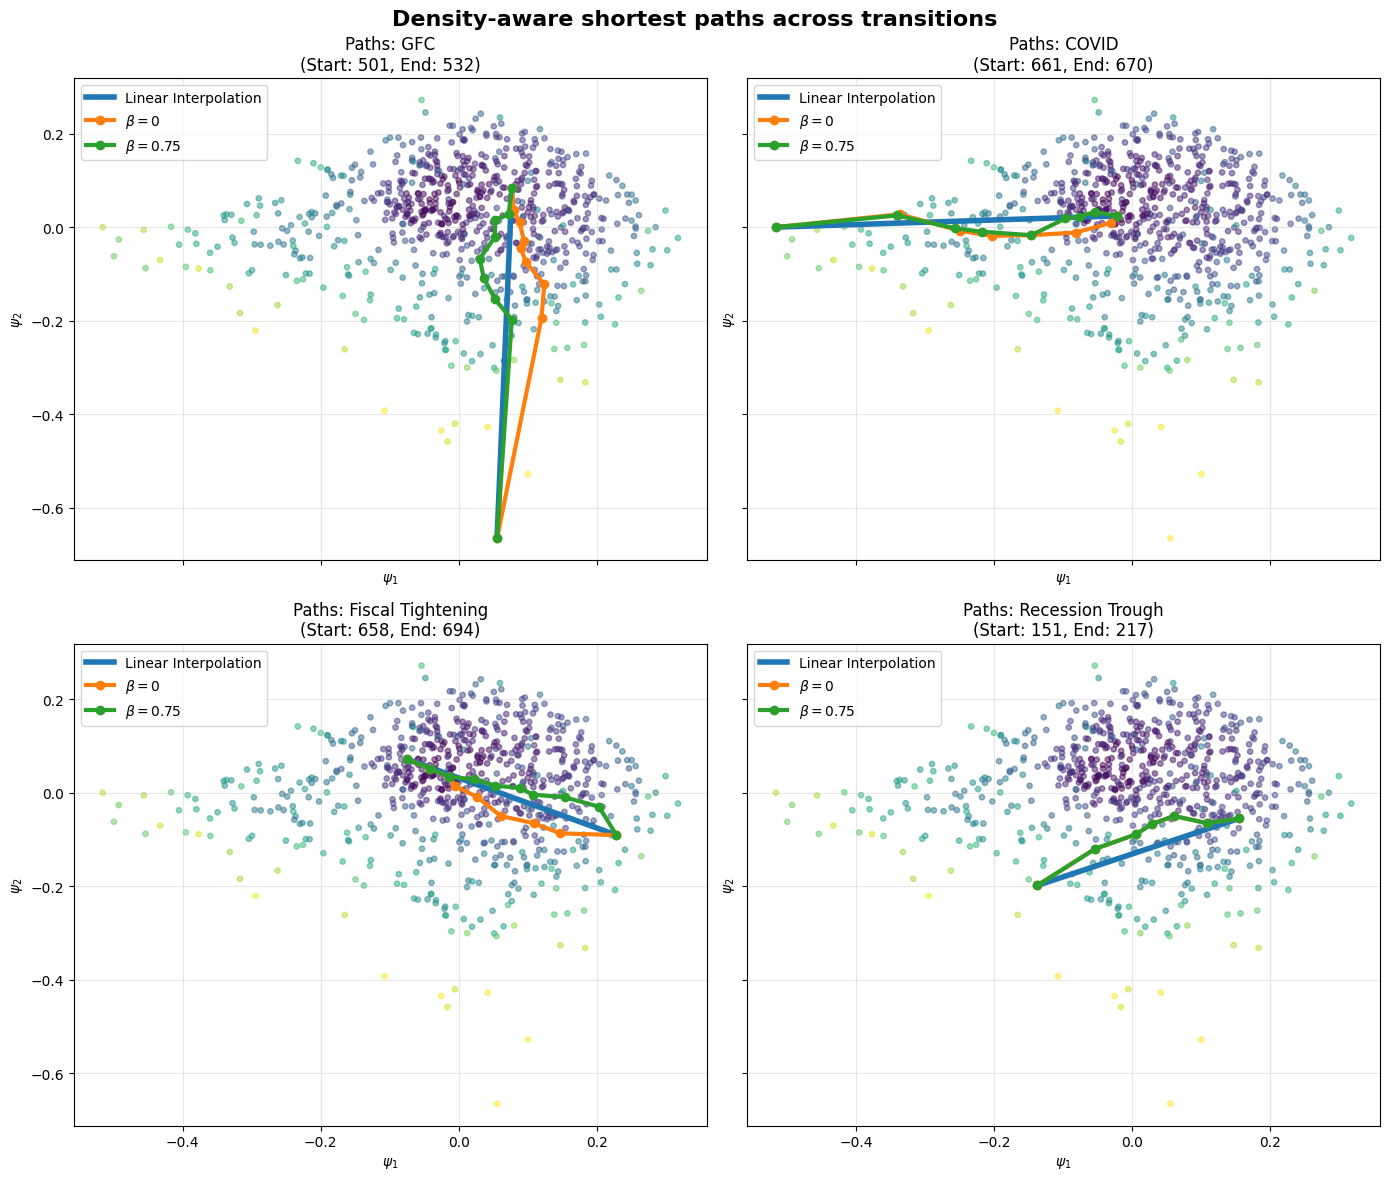

In [18]:
betas = [0, 0.75]

median_Dsq = np.median(squareform(pdist(Psi)**2)[np.triu_indices(N,1)])

# Create KNN adjacency matrix for our diffusion coordinates
A_dist = kneighbors_graph(Psi, n_neighbors=15, mode="distance", include_self=False)
A_dist_sym = A_dist.maximum(A_dist.T)

# Get a density potential vector for this embedding
rho, V = graph_degree_density(Psi, h=0.10*median_Dsq)

# Get the weight matrix w^(beta) for the cost of each path
A_beta_dict = {}
for beta in betas:
    A_beta_dict[beta] = density_aware_cost(A_dist_sym, V, beta)

fig, axes = plt.subplots(2, 2, figsize=(14, 12), sharex=True, sharey=True)
axes = axes.flatten()

stress_paths = {name: [] for name in points.keys()}

for i, (name, (start, end)) in enumerate(points.items()):
    ax = axes[i]
    sc = ax.scatter(Psi[:, 0], Psi[:, 1], c=V, s=15, cmap="viridis", alpha=0.5)
    ax.plot([Psi[start, 0], Psi[end, 0]], [Psi[start, 1], Psi[end, 1]], label="Linear Interpolation", linewidth=4)

    for beta in betas:
        # Shortest path based on different weight matrix
        _, pred = shortest_path(A_beta_dict[beta], directed=False, unweighted=False, return_predecessors=True)
        path = reconstruct_path(pred, start, end)
        stress_paths[name].append(path)

        P = Psi[path]
        ax.plot(P[:, 0], P[:, 1], marker="o", label=rf"$\beta={beta}$", linewidth=3)

    ax.set_xlabel(r"$\psi_1$"); ax.set_ylabel(r"$\psi_2$")
    ax.set_title(f"Paths: {name}\n(Start: {start}, End: {end})")
    ax.legend(); ax.grid(alpha=0.3)

plt.suptitle("Density-aware shortest paths across transitions", fontsize=16, weight="bold")
plt.tight_layout(); plt.show()


### (c) Why are historical endpoints used?

We use historical endpoints because they already have defined coordinates in the diffusion space. If we used unseen points, we would then need to find a way to embed them into our diffusion coordinate system, this can be done with the Nyström lift, but it's not the main focus of the dissertation. The fact that we are using real historical datapoints also means that there is a path between our two points that makes economic sense.

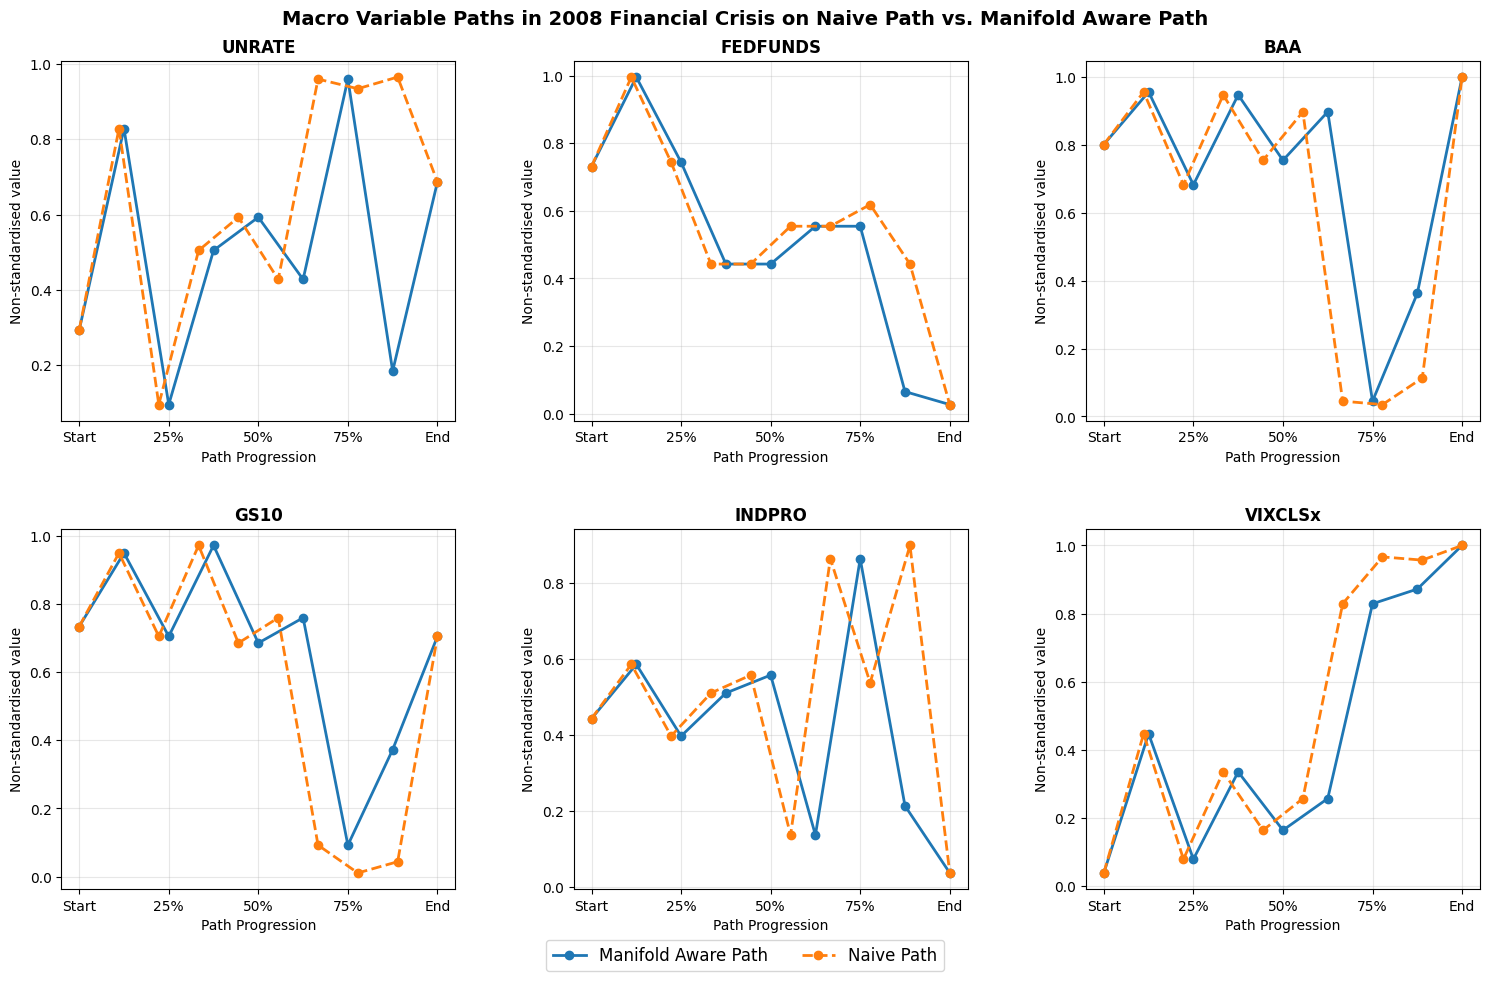

In [10]:
naive_path, dense_path = stress_paths["GFC"]

selected_vars = ["UNRATE", "FEDFUNDS", "BAA", "GS10", "INDPRO", "VIXCLSx"]

dense_path_step = df.iloc[dense_path][selected_vars].reset_index(drop=True)
naive_path_step = df.iloc[naive_path][selected_vars].reset_index(drop=True)
dense_x = np.linspace(0, 1, len(dense_path_step))
naive_x = np.linspace(0, 1, len(naive_path_step))

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes_flat = axes.flatten()

for i, var in enumerate(selected_vars):
    ax = axes_flat[i]
    ax.plot(dense_x, dense_path_step[var], marker="o", color="tab:blue", linewidth=2)
    ax.plot(naive_x, naive_path_step[var], marker="o", color="tab:orange", linewidth=2, linestyle="--")
    
    ax.set_title(var, fontsize=12, fontweight='bold')
    
    ax.set_xlabel("Path Progression"); ax.set_xlim(-0.05, 1.05)
    ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0])
    ax.set_xticklabels(["Start", "25%", "50%", "75%", "End"])
    ax.set_ylabel("Non-standardised value")
    ax.grid(alpha=0.3)

fig.legend(labels=["Manifold Aware Path", "Naive Path"], loc="lower center", ncol=2, fontsize=12,bbox_to_anchor=(0.5, 0.01))
plt.suptitle("Macro Variable Paths in 2008 Financial Crisis on Naive Path vs. Manifold Aware Path", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.subplots_adjust(bottom=0.10, hspace=0.3, wspace=0.3)
plt.show()